<a href="https://colab.research.google.com/github/Junhojuno/pytorch-tutorial/blob/master/RNN_Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### RNN으로 timeseries 데이터 예측하기 
- 주식데이터
- 예를들면, Cell에서 output으로 나오는 값의 dimension이 1이어야하는데
- RNN cell내부에서 hidden state계속 압축시켜주는건 아무래도 모델에 부담을 주게 된다.
- (이전 hidden state의 값을 합쳐서 다음으로 넘겨주는데 이를 dim 1로 압축시켜 넘겨줘야한다는 말이다.) --> 그게 그거 아닌가...압축이 잘 이해가 안된다.
- **그래서 보통 cell을 통과해서 나온 output을 fc layer를 통과시켜 dim1로 맞춰준다.**

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

In [0]:
# Scaling을 해줘서 모델이 출력값의 scale을 학습할 부담을 줄여준다.
# scaling function for input data (0~1)
def minmax_scaler(data):
    numerator = data - np.min(data, 0)
    denominator = np.max(data, 0) - np.min(data, 0)
    return numerator / (denominator + 1e-7)

# make dataset to input
def build_dataset(time_series, seq_length):
    dataX = []
    dataY = []
    for i in range(0, len(time_series) - seq_length):
        _x = time_series[i:i + seq_length, :]
        _y = time_series[i + seq_length, [-1]]  # Next close price(종가)
        print(_x, "->", _y)
        dataX.append(_x)
        dataY.append(_y)
    return np.array(dataX), np.array(dataY)

In [0]:
# hyper parameter
sequence_length = 7 # 일주일동안의 주식데이터로 8일째의 주식을 예측한다.
data_dim = 5 # Open(시가),High(최고가),Low(최저가),Volume(거래량),Close(종가)
hidden_dim = 10
output_dim = 1 # 마지막 fc layer가 맞춰야하는 Close(종가)를 의미
learning_rate = 0.01
iterations = 500

In [0]:
# data load
xy = np.loadtxt('data-02-stock_daily.csv', delimiter=",")
xy = xy[::-1] # 맨위가 가장 최근이어서 순서대로 해주기 위해 하나보다...

train_size = int(len(xy) * 0.7)
train_set = xy[0:train_size]
test_set = xy[train_size-sequence_length : ]

In [0]:
# train을 scaling한걸로 test를 해줘야하는거 아닌가...?
train_set = minmax_scaler(train_set)
test_set = minmax_scaler(test_set)

train_X, train_Y = build_dataset(train_set, sequence_length)
test_X, test_Y = build_dataset(test_set, sequence_length)

# to Tensor
train_X = torch.FloatTensor(train_X)
train_Y = torch.FloatTensor(train_Y)

test_X = torch.FloatTensor(test_X)
test_Y = torch.FloatTensor(test_Y)

In [0]:
class Net(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim, num_layers): # 여기서 num_layers란 2면 LSTM cell이 2개 --> stacked LSTM
    super(Net, self).__init__()
    self.rnn = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
    self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim, bias=True)
    
  def forward(self, x):
    x, _status = self.rnn(x)
    out = self.fc(x[:, -1]) # -1? 왜 x[:, -1]을 해주지..?
    return out

In [33]:
net = Net(input_dim=data_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=1)
net

Net(
  (rnn): LSTM(5, 10, batch_first=True)
  (fc): Linear(in_features=10, out_features=1, bias=True)
)

In [0]:
# cost function and optimizer
cost_func = nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr=learning_rate)

0 0.0012742531253024936
1 0.0012735992204397917
2 0.0012729476438835263
3 0.0012722985120490193
4 0.0012716514756903052
5 0.001271007233299315
6 0.0012703652027994394
7 0.0012697255006060004
8 0.001269088126718998
9 0.0012684535467997193
10 0.0012678209459409118
11 0.0012671909062191844
12 0.0012665630783885717
13 0.0012659376952797174
14 0.0012653147568926215
15 0.0012646940303966403
16 0.0012640758650377393
17 0.0012634595623239875
18 0.0012628460535779595
19 0.0012622348731383681
20 0.0012616259045898914
21 0.001261019380763173
22 0.0012604150688275695
23 0.0012598130851984024
24 0.0012592135462909937
25 0.0012586163356900215
26 0.0012580212205648422
27 0.0012574288994073868
28 0.0012568384408950806
29 0.001256250310689211
30 0.0012556646252050996
31 0.001255081151612103
32 0.001254500006325543
33 0.001253921422176063
34 0.001253344933502376
35 0.001252770540304482
36 0.0012521985918283463
37 0.001251628971658647
38 0.0012510614469647408
39 0.0012504963669925928
40 0.001249933498911

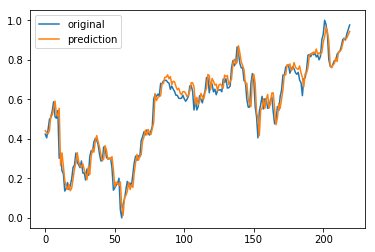

In [36]:
for i in range(iterations):
  
  optimizer.zero_grad()
  pred = net(train_X)
  cost = cost_func(pred, train_Y)
  cost.backward()
  optimizer.step()
  print(i, cost.item())

plt.plot(test_Y.data.numpy())
plt.plot(net(test_X).data.numpy())
plt.legend(['original','prediction'])
plt.show()